In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [2]:
from prophet import Prophet
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.diagnostics import cross_validation

c:\Users\Windows 10\Desktop\rosman-store-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [53]:
def calcular_metricas_completas(df, col_real='y', col_pred='yhat'):
    # Remove as linhas onde 'y' ou 'yhat' sejam NaN
    df_limpo = df.dropna(subset=[col_real, col_pred])
    
    if df_limpo.empty:
        raise ValueError("Após remover os nulos, não sobrou nenhuma linha para avaliar!")
        
    y_real = df_limpo[col_real]
    y_pred = df_limpo[col_pred]
    
    # 1. MSE
    mse = mean_squared_error(y_real, y_pred)
    
    # 2. RMSE
    rmse = np.sqrt(mse)
    
    # 3. MAE
    mae = mean_absolute_error(y_real, y_pred)
    
    # 4. MAPE (Ajustado para não explodir com zeros)
    # Calculamos apenas onde o real é diferente de 0 e tiramos a média
    erro_perc_abs = np.where(
        y_real != 0, 
        np.abs((y_real - y_pred) / y_real), 
        np.nan 
    )
    mape = np.nanmean(erro_perc_abs)
    
    # 5. MDAPE 
    mdape = np.nanmedian(erro_perc_abs)
    
    # 6. SMAPE
    numerador = np.abs(y_pred - y_real)
    denominador = np.abs(y_real) + np.abs(y_pred)
    smape_linhas = np.divide(numerador, denominador, out=np.zeros_like(numerador), where=denominador!=0)
    smape = np.mean(smape_linhas) * 2 
    
    # ==========================================
    # FORMATAÇÃO PARA LEITURA HUMANA
    # Multiplicamos as métricas percentuais por 100 e formatamos as strings
    # ==========================================
    resultados = {
        'Métrica': ['MSE', 'RMSE', 'MAE', 'MAPE', 'MDAPE', 'SMAPE'],
        'Valor (Formatado)': [
            f"{mse:,.2f}",               # Formato de float normal com 2 casas
            f"{rmse:,.2f}", 
            f"{mae:,.2f}", 
            f"{mape * 100:,.2f}%",       # Multiplica por 100 e adiciona o símbolo de %
            f"{mdape * 100:,.2f}%", 
            f"{smape * 100:,.2f}%"
        ]
    }
    
    return pd.DataFrame(resultados)

In [23]:
df = pd.read_csv('./data/train.csv')
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_15920\2732287264.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/train.csv')


In [24]:
df_sample = df[df['Store'] == 1]

In [ ]:
#Dados totais
# 2013-01-01 00:00:00
# 2015-07-31 00:00:00

#Treinar com dados de 2013-01-01 até 2015-06-30
#Validar com dados de 2015-07-01 até 2015-07-31

In [25]:
df_copy = df_sample[['Date', 'Sales']]
df_copy = df_copy.rename(columns={'Date': 'ds', 'Sales': 'y'})
df_copy[['y']] = df_copy[['y']].apply(pd.to_numeric)

In [26]:
df_train = df_copy[(df_copy['ds'] < '2015-07-01')]
df_test = df_copy[(df_copy['ds'] >= '2015-07-01') & (df_copy['ds'] <= '2015-07-31')]

In [27]:
m = Prophet()
model = m.fit(df_train)

23:30:35 - cmdstanpy - INFO - Chain [1] start processing
23:30:35 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
future = model.make_future_dataframe(periods=30, freq='D')
forecast = model.predict(future)

In [35]:
df_final = pd.merge(df_test, forecast, on='ds', how='left')

In [37]:
df_final[['ds', 'y', 'yhat']].head()

,ds,y,yhat
0,2015-07-31,5263,NaN
1,2015-07-30,5020,3811.607606
2,2015-07-29,4782,4214.423661
3,2015-07-28,5011,4445.664351
4,2015-07-27,6102,4753.558752


In [38]:
df_final[['ds', 'y', 'yhat']].tail()

,ds,y,yhat
26,2015-07-05,0,-333.525766
27,2015-07-04,4797,4612.792838
28,2015-07-03,4665,4152.719552
29,2015-07-02,5558,3698.913136
30,2015-07-01,5223,4067.077181


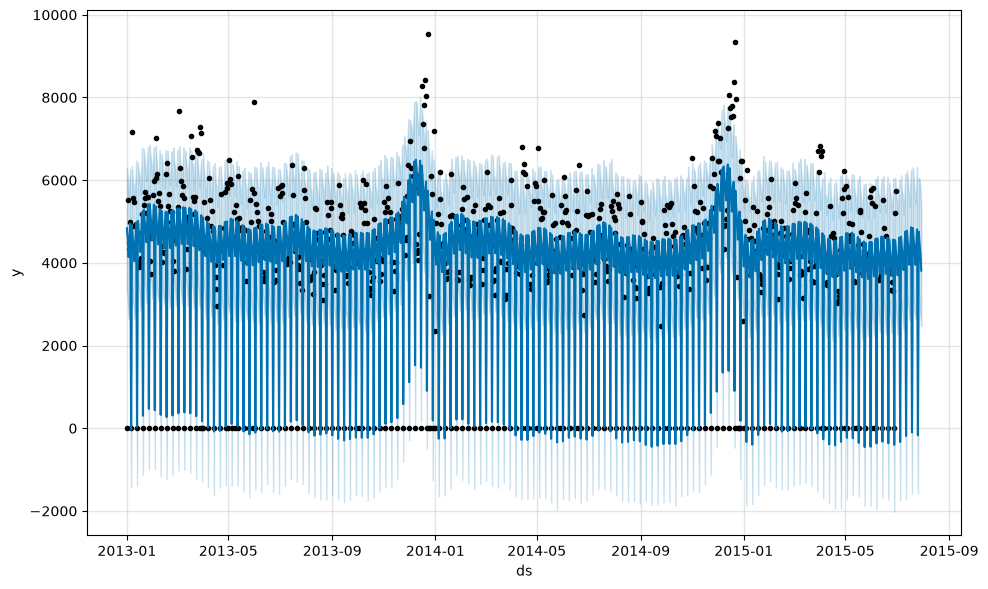

In [39]:
plot1 = model.plot(forecast)

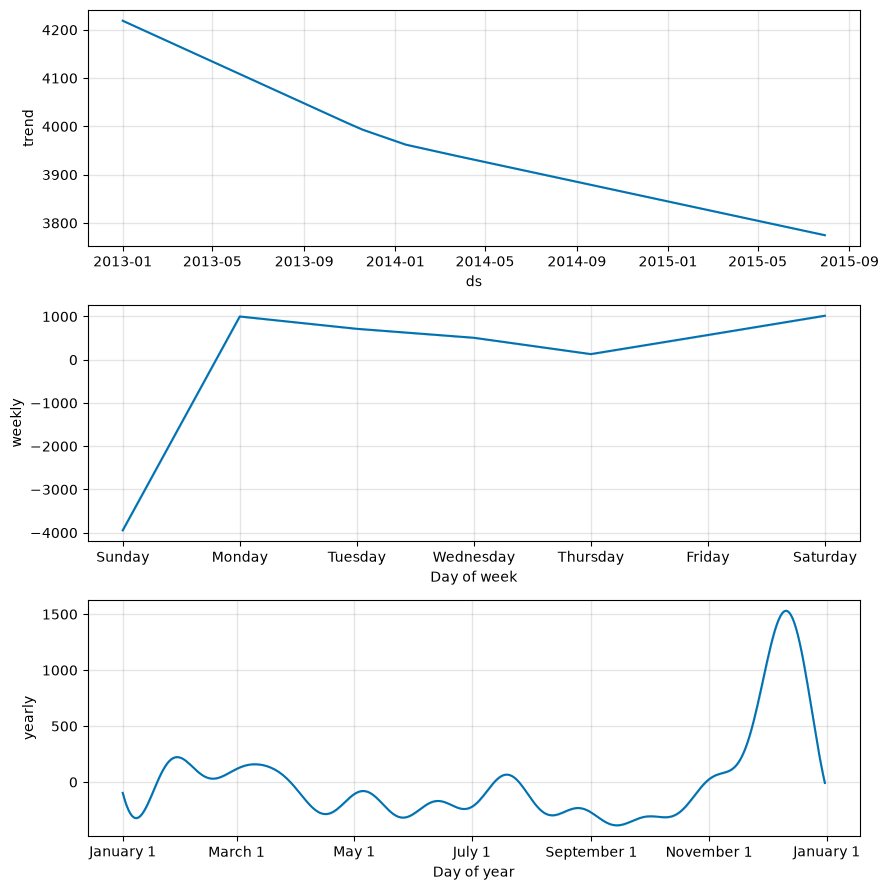

In [40]:
plot2 = model.plot_components(forecast)

In [54]:
results = calcular_metricas_completas(df_final, col_real='y', col_pred='yhat')

In [55]:
results.head()

,Métrica,Valor (Formatado)
0,MSE,"517,021.18"
1,RMSE,719.04
2,MAE,586.76
3,MAPE,14.52%
4,MDAPE,10.83%


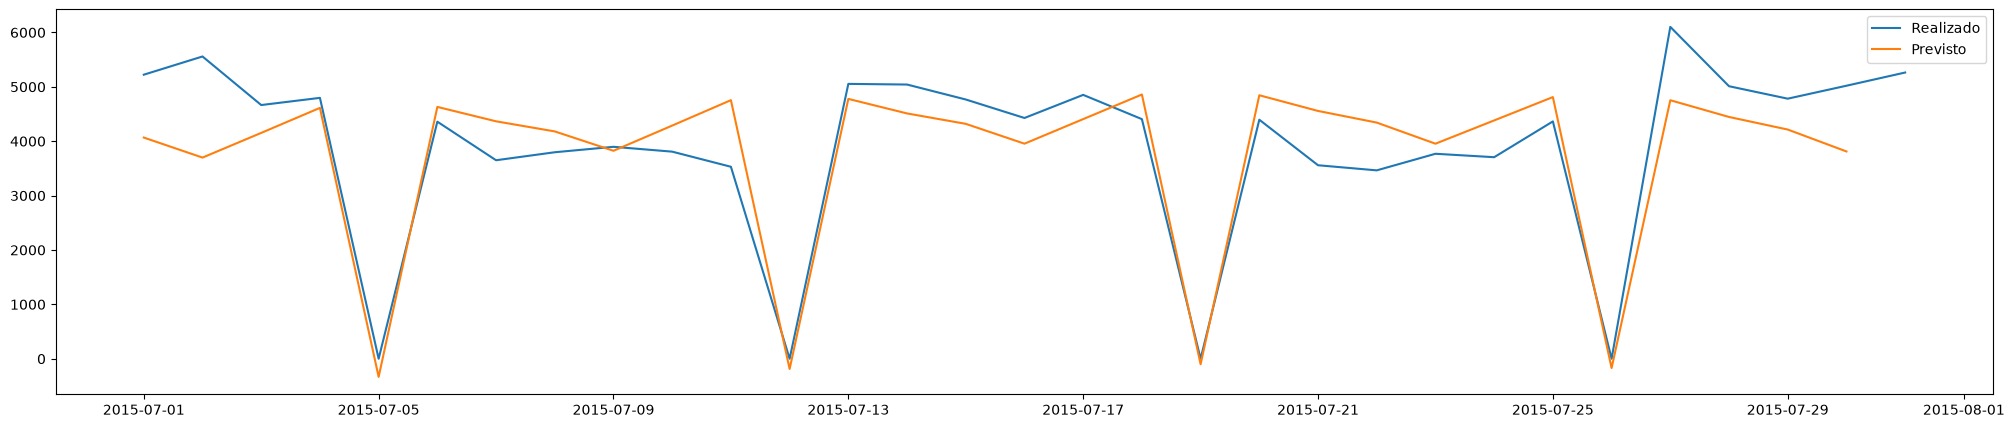

In [58]:
plt.figure(figsize=(25, 5))
plt.plot(df_final['ds'], df_final['y'], label='Realizado')
plt.plot(df_final['ds'], df_final['yhat'], label='Previsto')
plt.legend()
plt.show()